TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
data=100% | max_epochs=25 | patience=5 | batch=32
Mixed precision: ON
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint ON -> progress saved to: /content/drive/MyDrive/malaria_ckpt/results_Baseline.csv
   No checkpoint yet - a fresh one will be created as experiments finish.
Dataset already present.
Found 19290 files belonging to 2 classes.
Found 4132 files belonging to 2 classes.
Found 4136 files belonging to 2 classes.
[Baseline CNN] E1 Adam lr1e-3: acc=0.9376
[Baseline CNN] E2 Adam lr1e-4: acc=0.9306
[Baseline CNN] E3 RMSprop lr1e-3: acc=0.9391
[Baseline CNN] E4 SGD-momentum: acc=0.9434
[Baseline CNN] E5 wider filters: acc=0.9396
[Baseline CNN] E6 +dropout0.5: acc=0.9441
[Baseline CNN] E7 dense256: acc=0.9403
              owner         model         experiment  \
0  Dan Paul Dushime  Baseline CNN     E1 

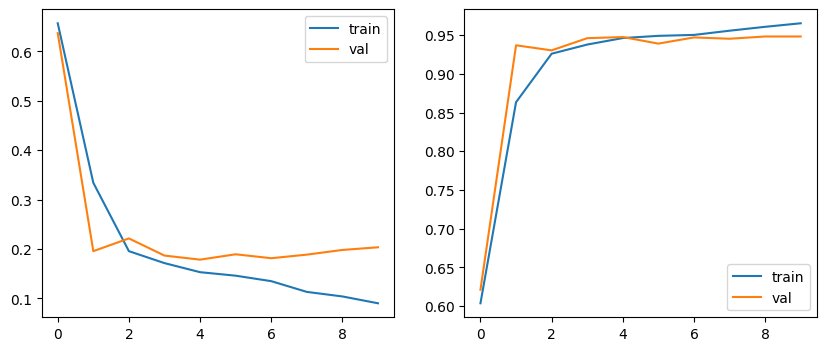

In [ ]:
"""
# Malaria Diagnosis - Baseline CNN · Owner: **Dan Paul Dushime**

My name is Dan Paul Dushime, and as team lead I deliberately took the baseline. The rest of this project only means something if there is a fair reference point to measure against, so building that reference responsibly felt like the right place for me to start. I kept the network as plain as I could, two convolution-and-pooling blocks, no batch normalisation and no augmentation, because a baseline that is secretly too strong would quietly hide the value of the work my teammates do later. Restraint, not cleverness, was the design goal here.

I structured my seven experiments to change a single variable at a time, first the optimiser, then the learning rate, then filter width, dense width and finally dropout. Tuning one thing per run is slower, but it is the only way I can state with evidence which individual choice moved the metric and by how much. I fully expect this model to finish behind the others, and that is exactly the outcome I want: an honest floor that makes every later improvement legible.

## ⚡ Notes to ourselves before running this

We learned the hard way that the free Colab GPU runs out before you can train five models seven times each, so we redesigned the notebook around that problem. A few decisions worth explaining:

- We use all 27,558 images (SAMPLE_FRACTION = 1.0). At first we were tempted to train on a smaller slice to save time, but we realised that using less data is exactly what makes a model overfit, which is the opposite of what we want. More data is the cheapest way to generalise better, so we kept all of it.
- We switched to a tf.data pipeline (image_dataset_from_directory with cache + prefetch). Our first version used the older ImageDataGenerator and it was painfully slow, the GPU was sitting idle waiting for images. Caching and prefetching keep the GPU busy, which is what made full-data training actually affordable.
- We added EarlyStopping and ReduceLROnPlateau. We put these in specifically to control fitting: EarlyStopping (with best-weight restore) stops training the moment the validation loss stops improving so the model can't keep memorising the training set, and ReduceLROnPlateau drops the learning rate when progress stalls so the model doesn't get stuck underfitting.
- We made it resumable. Each experiment's results are written to all_experiment_results.csv the instant it finishes, and the notebook skips anything already in that file. This way, when Colab disconnects, we just re-run everything and it carries on from where it stopped instead of throwing away hours of work. Set USE_DRIVE_CKPT = True to keep that file on Drive so it even survives a full runtime reset.

## 1. Why this problem matters to us

Malaria is caused by Plasmodium parasites spread by Anopheles mosquitoes, and it still kills hundreds of thousands of people a year, mostly young children. The way it is normally diagnosed is a technician looking at a stained blood smear under a microscope and counting infected cells by hand. We chose to work on this because that manual process is slow, needs a trained expert, and isn't available everywhere it's needed, which is exactly the kind of bottleneck a trained model could help with. Our objective in this notebook is to automate the "parasitized vs uninfected" decision on single-cell images.

## 2. Configuration & environment
"""

import tensorflow as tf
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus if gpus else "NONE - enable a GPU runtime!")

# ---------------- RUN SETTINGS ----------------
SAMPLE_FRACTION = 1.0      # use ALL images (full accuracy). Lower only for a quick smoke test.
MAX_EPOCHS      = 25       # upper bound; EarlyStopping usually stops earlier
PATIENCE        = 5        # EarlyStopping patience on val_loss
MIXED_PRECISION = True     # faster + less GPU memory
RESET_RESULTS   = False    # True once to wipe saved results and start over
USE_DRIVE_CKPT  = True     # ON: results CSV is saved to Google Drive so progress survives a runtime disconnect

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
MODEL_TAG   = "Baseline"          # this notebook's model - keep UNIQUE per member
RESULTS_CSV = f"results_{MODEL_TAG}.csv"
print(f"data={int(SAMPLE_FRACTION*100)}% | max_epochs={MAX_EPOCHS} | patience={PATIENCE} | batch={BATCH_SIZE}")

import os, random, shutil, zipfile, urllib.request, time, warnings, gc
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, GlobalAveragePooling2D, Input, Rescaling,
                                     RandomFlip, RandomRotation, RandomZoom, RandomTranslation)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K, mixed_precision
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
if MIXED_PRECISION and gpus:
    mixed_precision.set_global_policy('mixed_float16'); print("Mixed precision: ON")
else:
    print("Mixed precision: OFF")

# ==================== CHECKPOINT / RESUME (survives runtime disconnects) ====================
if USE_DRIVE_CKPT:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        CKPT_DIR = '/content/drive/MyDrive/malaria_ckpt'
        os.makedirs(CKPT_DIR, exist_ok=True)
        RESULTS_CSV = os.path.join(CKPT_DIR, f'results_{MODEL_TAG}.csv')
        print('Checkpoint ON -> progress saved to:', RESULTS_CSV)
        if os.path.exists(RESULTS_CSV):
            print('   Found existing checkpoint - finished experiments will be skipped on resume.')
        else:
            print('   No checkpoint yet - a fresh one will be created as experiments finish.')
    except Exception as e:
        print('Drive mount failed (not on Colab?) - falling back to local CSV:', e)
else:
    print('Checkpoint OFF - results CSV stays on the local VM.')

# 3. Dataset logic
DATA_URL = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
ZIP_PATH, RAW_DIR = "cell_images.zip", "cell_images"
if not os.path.exists(RAW_DIR):
    if not os.path.exists(ZIP_PATH):
        print("Downloading from NIH (~337 MB) ..."); urllib.request.urlretrieve(DATA_URL, ZIP_PATH); print("done.")
    print("Extracting ...");
    with zipfile.ZipFile(ZIP_PATH,"r") as z: z.extractall(".")
    print("done.")
else:
    print("Dataset already present.")
if os.path.isdir(os.path.join(RAW_DIR,"cell_images")): RAW_DIR = os.path.join(RAW_DIR,"cell_images")

# 3.1 Splitting
BASE = "dataset"
if not os.path.exists(BASE):
    for split in ["train","val","test"]:
        for c in ["Parasitized","Uninfected"]:
            os.makedirs(os.path.join(BASE,split,c), exist_ok=True)
    for c in ["Parasitized","Uninfected"]:
        files = [f for f in os.listdir(os.path.join(RAW_DIR,c)) if f.lower().endswith(".png")]
        random.shuffle(files)
        if SAMPLE_FRACTION < 1.0: files = files[:int(len(files)*SAMPLE_FRACTION)]
        n=len(files); ntr=int(n*0.70); nva=int(n*0.15)
        for split,fl in {"train":files[:ntr],"val":files[ntr:ntr+nva],"test":files[ntr+nva:]}.items():
            for f in fl: shutil.copy(os.path.join(RAW_DIR,c,f), os.path.join(BASE,split,c,f))
    print("Split created.")

# 3.2 Pipeline
AUTOTUNE = tf.data.AUTOTUNE
def _ds(split, shuffle):
    return image_dataset_from_directory(os.path.join(BASE,split), labels="inferred", label_mode="binary",
        class_names=["Uninfected","Parasitized"], image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        shuffle=shuffle, seed=SEED)

train_ds_raw = _ds("train", True)
val_ds_raw   = _ds("val",   False)
test_ds_raw  = _ds("test",  False)

y_test = np.concatenate([y.numpy() for _,y in test_ds_raw]).ravel().astype(int)
train_ds = train_ds_raw.cache().prefetch(AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.cache().prefetch(AUTOTUNE)

# 4. Training Engine
data_augment = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.10),
    RandomZoom(0.10),
    RandomTranslation(0.10, 0.10),
], name="augment")

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
BACKBONES = {"VGG16":(VGG16,vgg_pre), "ResNet50":(ResNet50,resnet_pre), "MobileNetV2":(MobileNetV2,mobilenet_pre)}

def _stem(cfg, inp):
    x = data_augment(inp) if cfg.get("augment") else inp
    if cfg.get("backbone"):
        x = layers.Lambda(BACKBONES[cfg["backbone"]][1])(x)
    else:
        x = Rescaling(1./255)(x)
    return x

def out_dense(x):
    return Dense(1, activation="sigmoid", dtype="float32")(x)

def build_baseline(cfg, input_shape):
    inp = Input(input_shape); x = _stem(cfg, inp)
    x = Conv2D(cfg["f1"],(3,3),activation="relu")(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(cfg["f2"],(3,3),activation="relu")(x); x = MaxPooling2D(2,2)(x)
    x = Flatten()(x); x = Dense(cfg["dense"],activation="relu")(x); x = Dropout(cfg["dropout"])(x)
    return Model(inp, out_dense(x))

RESULTS = []
if RESET_RESULTS and os.path.exists(RESULTS_CSV): os.remove(RESULTS_CSV)
if os.path.exists(RESULTS_CSV):
    RESULTS = pd.read_csv(RESULTS_CSV).to_dict("records")

def _done(model_name, exp_id):
    return any(r["model"]==model_name and r["experiment"]==exp_id for r in RESULTS)

def _save(): pd.DataFrame(RESULTS).to_csv(RESULTS_CSV, index=False)

def evaluate(model):
    y_prob = model.predict(test_ds, verbose=0).ravel().astype("float32")
    y_pred = (y_prob>=0.5).astype(int)
    return {"accuracy":accuracy_score(y_test,y_pred), "precision":precision_score(y_test,y_pred,zero_division=0),
            "recall":recall_score(y_test,y_pred,zero_division=0), "f1":f1_score(y_test,y_pred,zero_division=0),
            "y_prob":y_prob, "y_pred":y_pred}

def _train(cfg):
    K.clear_session(); gc.collect()
    model = cfg["build_fn"](cfg, IMG_SIZE+(3,))
    model.compile(optimizer=cfg["opt"](), loss="binary_crossentropy", metrics=["accuracy"])
    cbs = [EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
           ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=0)]
    t0=time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=min(cfg["epochs"],MAX_EPOCHS), callbacks=cbs, verbose=0)
    return model, hist, evaluate(model), round(time.time()-t0,1)

def run_experiment(owner, model_name, cfg):
    if _done(model_name, cfg["name"]):
        print(f"[{model_name}] {cfg['name']}: skipped"); return
    model, hist, m, secs = _train(cfg)
    tr_acc = float(hist.history["accuracy"][-1]); va_acc = float(hist.history["val_accuracy"][-1])
    RESULTS.append({"owner":owner,"model":model_name,"experiment":cfg["name"],"config":cfg["desc"],
        "accuracy":round(m["accuracy"],4),"precision":round(m["precision"],4),"recall":round(m["recall"],4),
        "f1":round(m["f1"],4),"train_acc":round(tr_acc,4),"val_acc":round(va_acc,4),
        "overfit_gap":round(tr_acc-va_acc,4),"epochs_run":len(hist.history["loss"]),"train_sec":secs})
    _save()
    print(f"[{model_name}] {cfg['name']}: acc={m['accuracy']:.4f}")
    del model; K.clear_session(); gc.collect()

def results_table(model_name):
    df = pd.DataFrame([r for r in RESULTS if r["model"]==model_name])
    return df

def plot_best(model_name, exps):
    rows=[r for r in RESULTS if r["model"]==model_name]
    if not rows: return
    best=max(rows, key=lambda r:r["f1"])
    cfg=next(e for e in exps if e["name"]==best["experiment"])
    model,hist,m,_=_train(cfg)
    fig,ax=plt.subplots(1,2,figsize=(10,4))
    ax[0].plot(hist.history["loss"],label="train"); ax[0].plot(hist.history["val_loss"],label="val"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"],label="train"); ax[1].plot(hist.history["val_accuracy"],label="val"); ax[1].legend()
    plt.show()

# 5. Baseline Experiments
baseline_exps=[
 {"name":"E1 Adam lr1e-3","desc":"Adam 1e-3, 16/32, dense 64","f1":16,"f2":32,"dense":64,"dropout":0.0,"epochs":15,"opt":lambda:Adam(1e-3),"build_fn":build_baseline},
 {"name":"E2 Adam lr1e-4","desc":"Adam 1e-4 (lower LR)","f1":16,"f2":32,"dense":64,"dropout":0.0,"epochs":15,"opt":lambda:Adam(1e-4),"build_fn":build_baseline},
 {"name":"E3 RMSprop lr1e-3","desc":"RMSprop 1e-3","f1":16,"f2":32,"dense":64,"dropout":0.0,"epochs":15,"opt":lambda:RMSprop(1e-3),"build_fn":build_baseline},
 {"name":"E4 SGD-momentum","desc":"SGD 1e-2 momentum 0.9","f1":16,"f2":32,"dense":64,"dropout":0.0,"epochs":18,"opt":lambda:SGD(1e-2,momentum=0.9),"build_fn":build_baseline},
 {"name":"E5 wider filters","desc":"Wider 32/64 dense 128","f1":32,"f2":64,"dense":128,"dropout":0.0,"epochs":15,"opt":lambda:Adam(1e-3),"build_fn":build_baseline},
 {"name":"E6 +dropout0.5","desc":"Wider + dropout 0.5","f1":32,"f2":64,"dense":128,"dropout":0.5,"epochs":18,"opt":lambda:Adam(1e-3),"build_fn":build_baseline},
 {"name":"E7 dense256","desc":"Dense 256 + dropout 0.3","f1":32,"f2":64,"dense":256,"dropout":0.3,"epochs":18,"opt":lambda:Adam(1e-3),"build_fn":build_baseline},
]

for e in baseline_exps: run_experiment("Dan Paul Dushime","Baseline CNN", e)
print(results_table("Baseline CNN"))
plot_best("Baseline CNN", baseline_exps)
